In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/utkarshsahare/hell-week/taxis.csv


In [2]:
df = pd.read_csv(r'/kaggle/input/datasets/utkarshsahare/hell-week/taxis.csv')
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   object 
 1   dropoff          6433 non-null   object 
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   object 
 9   payment          6389 non-null   object 
 10  pickup_zone      6407 non-null   object 
 11  dropoff_zone     6388 non-null   object 
 12  pickup_borough   6407 non-null   object 
 13  dropoff_borough  6388 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 703.7+ KB


In [4]:
df.shape

(6433, 14)

## **EDA**

## change Style

In [5]:
import matplotlib.pyplot as plt

In [6]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [7]:
plt.style.use('Solarize_Light2')

In [8]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [9]:
list_columns=['distance', 'fare', 'tip', 'tolls',
       'total']

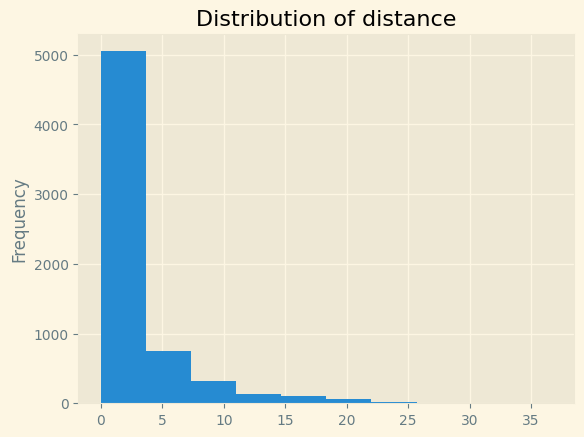

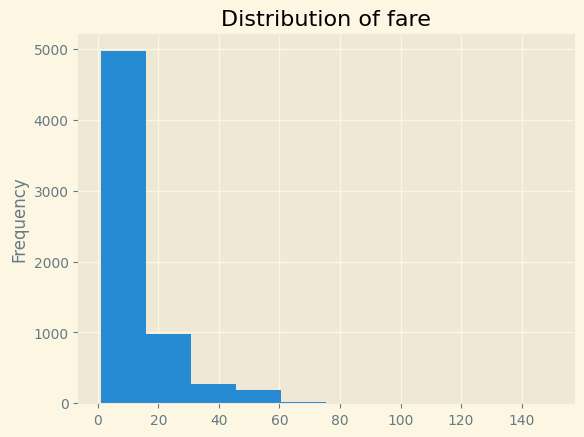

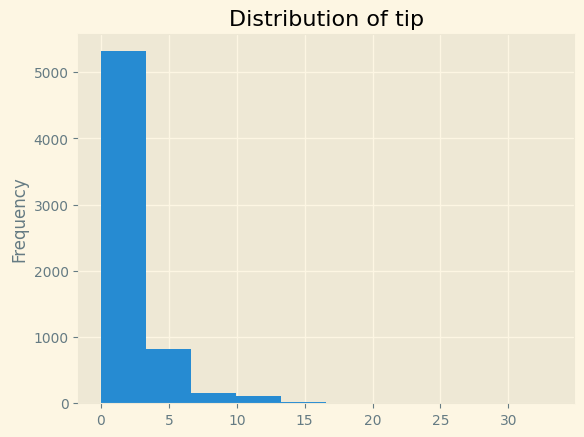

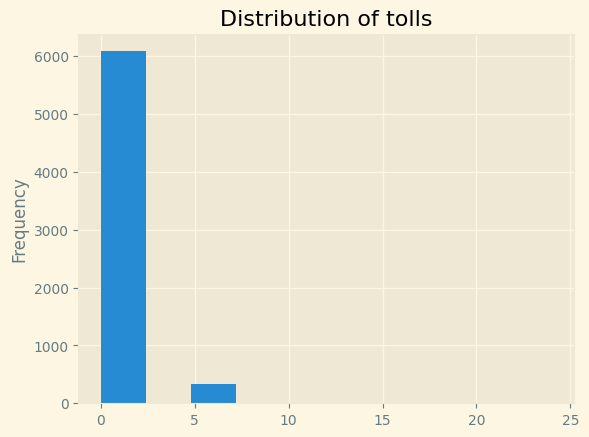

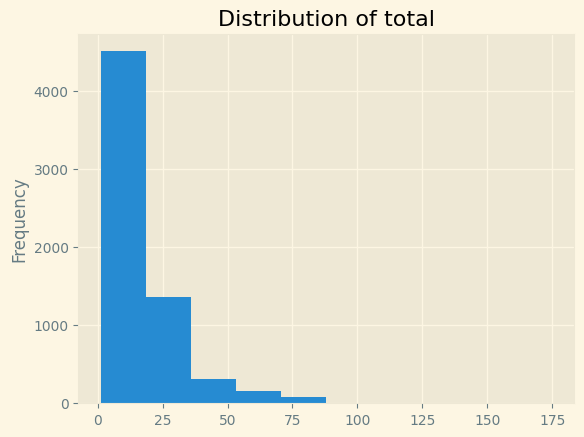

In [10]:
for feat in list_columns:
    df[feat].plot(kind='hist')
    plt.title(f'Distribution of {feat}')
    plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pickup           6433 non-null   object 
 1   dropoff          6433 non-null   object 
 2   passengers       6433 non-null   int64  
 3   distance         6433 non-null   float64
 4   fare             6433 non-null   float64
 5   tip              6433 non-null   float64
 6   tolls            6433 non-null   float64
 7   total            6433 non-null   float64
 8   color            6433 non-null   object 
 9   payment          6389 non-null   object 
 10  pickup_zone      6407 non-null   object 
 11  dropoff_zone     6388 non-null   object 
 12  pickup_borough   6407 non-null   object 
 13  dropoff_borough  6388 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 703.7+ KB


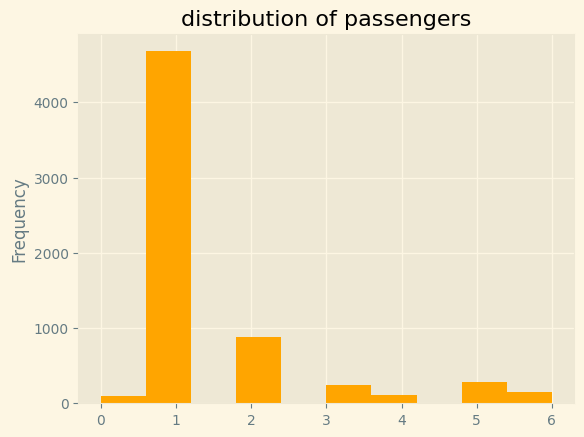

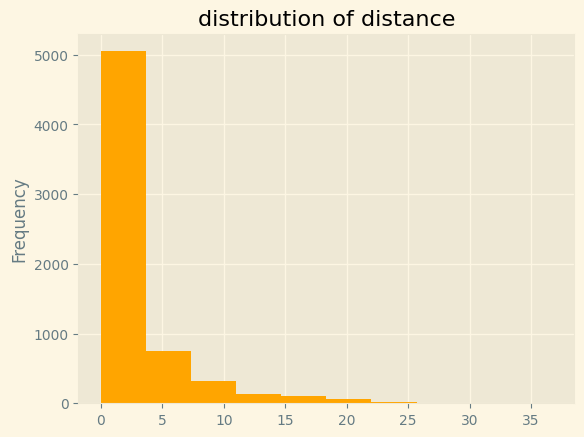

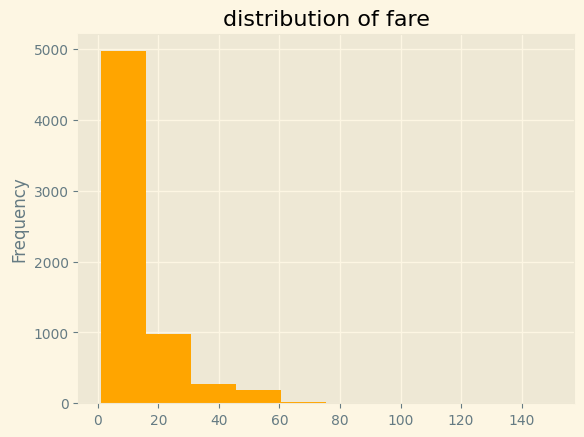

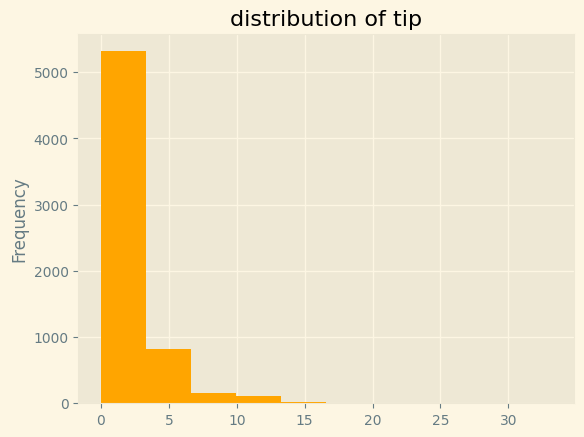

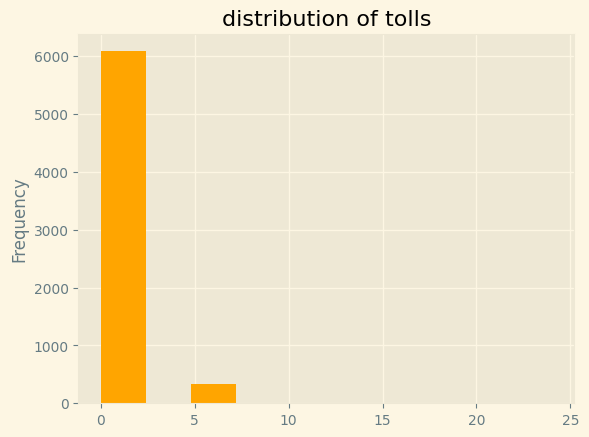

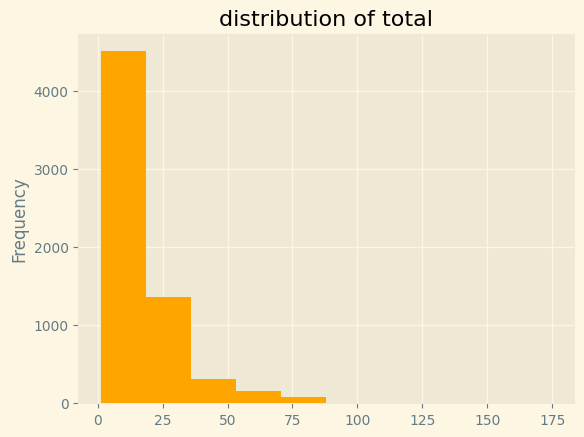

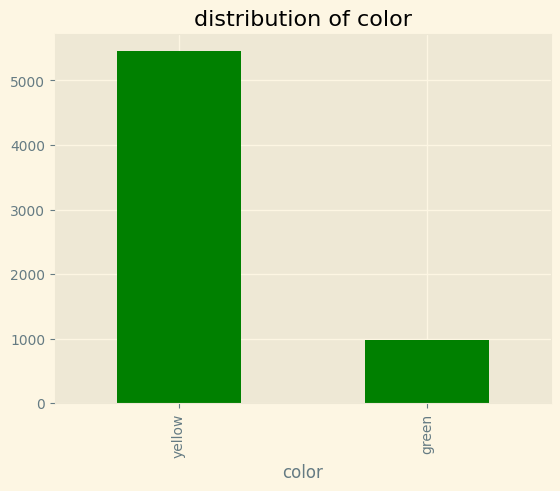

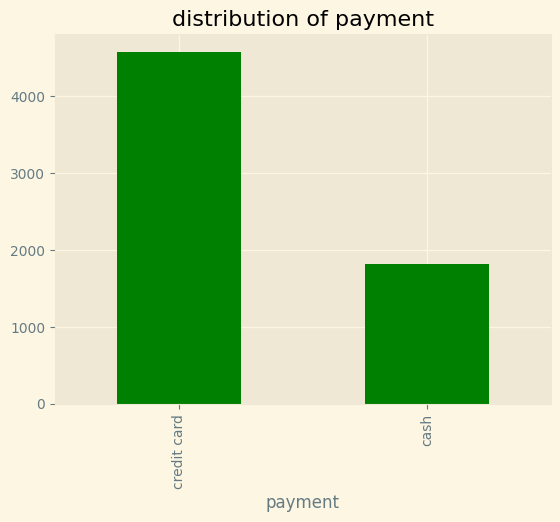

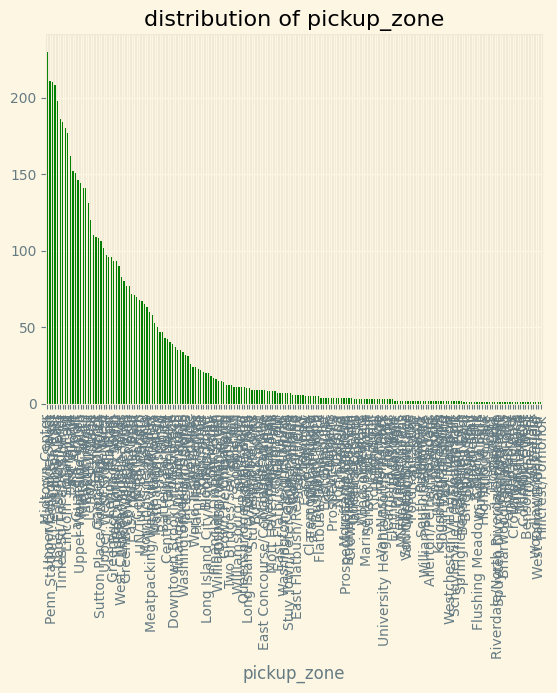

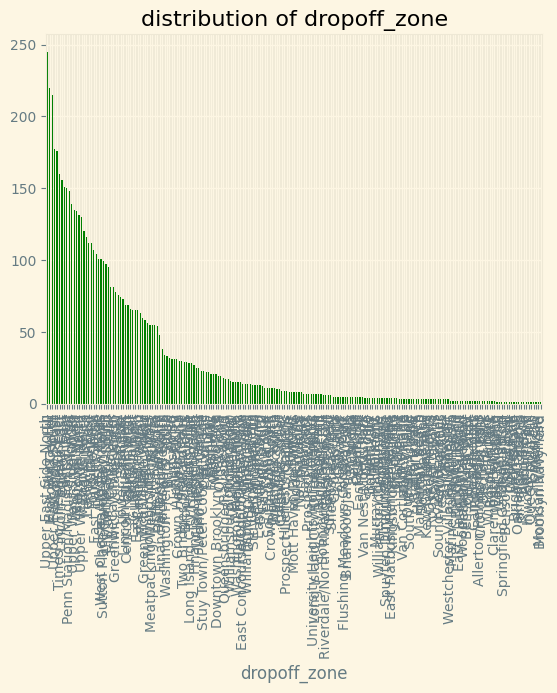

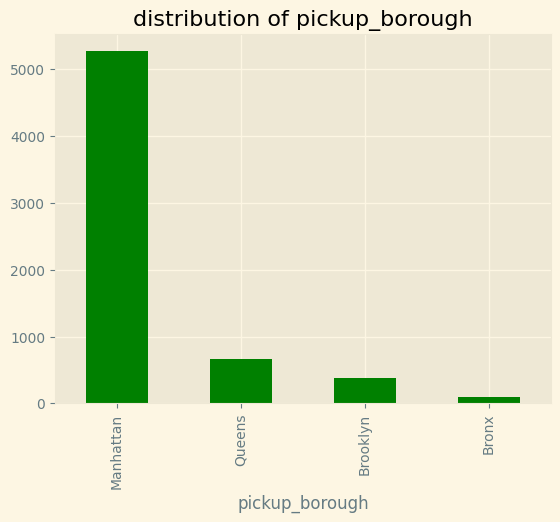

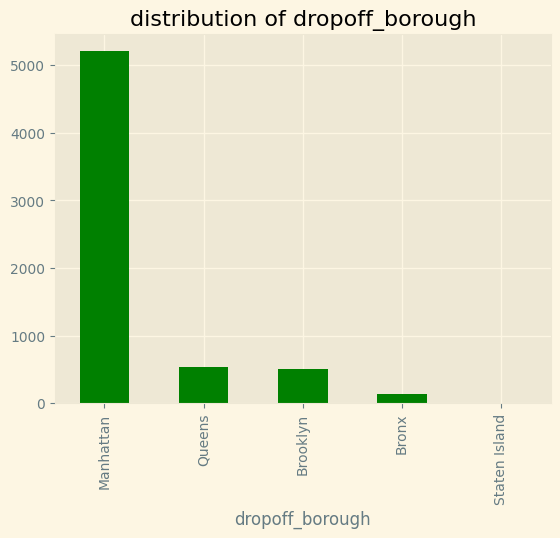

In [12]:
for feat in df.columns[2:]:
    if df[feat].dtype == 'object':
        df[feat].value_counts().plot(kind='bar',color = 'green')
    else :
        df[feat].plot(kind='hist',color='orange')
    plt.title(f'distribution of {feat}')
    plt.show()

Observation : 
* most trips are for 1 passengers only
* distance,fare,tip,tolls have exponential distribution
* color two classes green and yellow
* mode of payment is more through credit cards than cash
* pickup and dropoff's have many unique category with several dominant classes
* pickup_borough 4 classes
* dropoff_borough 5 classes


In [13]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

<Axes: >

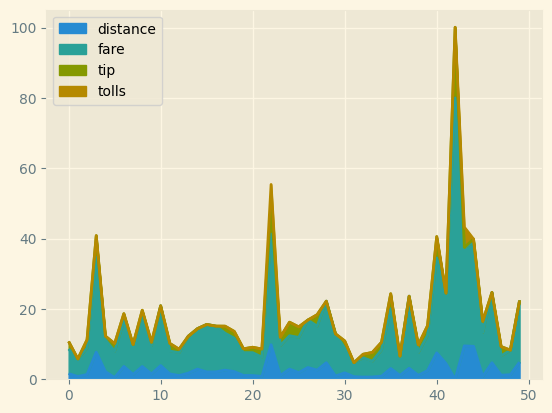

In [14]:
df[['distance', 'fare', 'tip', 'tolls']][:50].plot(kind='area')

This is a Stacked Area Chart, which is like a line chart where the areas under the lines are filled with color and "piled" on top of each other.

In simple terms, here is what is happening in the image:

The Total Height: The very top edge of the entire colored shape shows the total value (likely the total cost of a trip) at any given point on the x-axis (0 to 50).

The "Slices": Each color represents a different category (distance, fare, tip, and tolls).

### Proportions: By looking at the thickness of a color band, you can see which part contributed most to the total. For example, the teal (fare) is clearly the largest expense in almost every trip.

The Spikes: You can easily see where costs skyrocketed (like near point 42). Because it's stacked, you can see that the spike was caused primarily by a huge jump in the fare and distance, while the tip and tolls stayed relatively small.

<Axes: title={'center': 'Area plot Taxis'}>

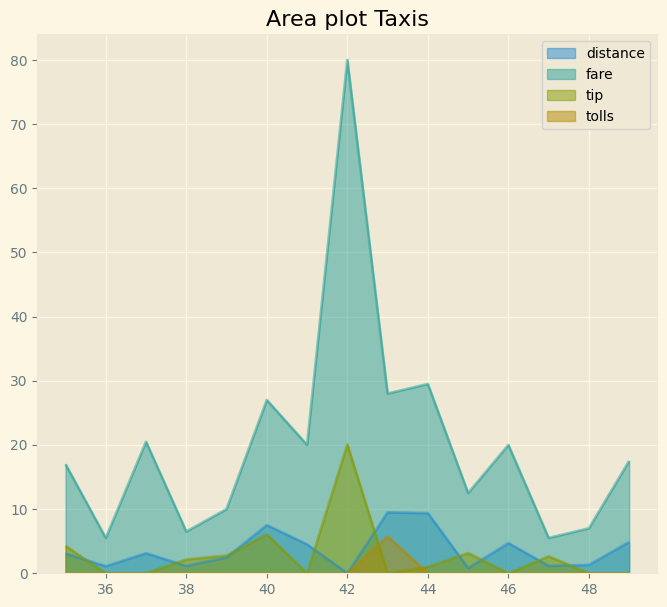

In [15]:
df[['distance', 'fare', 'tip', 'tolls']][35:50].plot(kind='area',figsize=(8,7),stacked = False,title='Area plot Taxis')

### Observation:the feature 'fare' has most width hence most contributing

<Axes: ylabel='Frequency'>

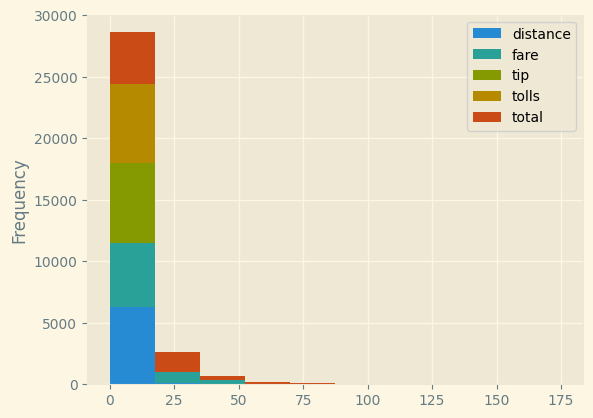

In [16]:
df[['distance', 'fare', 'tip', 'tolls','total']].plot(kind='hist',stacked=True)

<Axes: ylabel='Frequency'>

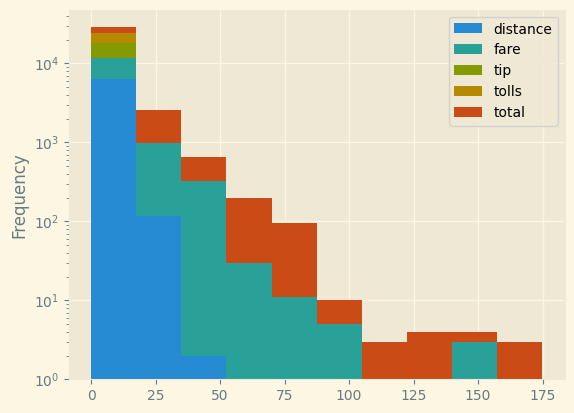

In [17]:
df[['distance', 'fare', 'tip', 'tolls','total']].plot(kind='hist',log=True,stacked=True)

<Axes: ylabel='Frequency'>

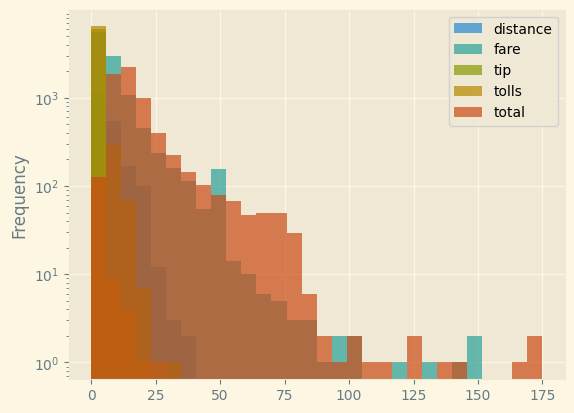

In [18]:
df[['distance', 'fare', 'tip', 'tolls','total']].plot(kind='hist',log=True,stacked=False,alpha=.7,bins=30)

### **It shows us how common different prices and distances are.**
* The Colors (The Legend): In the top right corner, you'll see a key. Each color stands for a different part of a car ride: the distance traveled, the base fare, the tip, the tolls, and the final total cost.

* The Bottom Edge (The X-Axis): The numbers running along the bottom (0, 25, 50, up to 175) show the "Amount." For distance, this is likely miles. For fare, tip, tolls, and total, this is dollars. The further right you look, the more expensive or longer the trip is.

* The Left Edge (The Y-Axis): This shows "Frequency"—simply put, how many trips had that specific price or distance.

* Most rides are short and cheap: See that massive block of color bunched up between 0 and 20? That tells us that the vast majority of rides—literally thousands of them—are very short distances and cost very little money.

* Tolls and large tips are rare: The gold (tolls) and olive-green (tips) bars are mostly stacked way up high right at the $0 to $10 mark. This means for most rides, passengers aren't paying tolls, and their tips are relatively small

* Long, expensive trips do happen, but rarely: Look at the blocks of color trailing off to the right side of the chart (past 75, 100, and up to 175). Those are the long, pricey trips. Because of our special left-side scale, we can see that while thousands of trips cost $10, only one or two trips cost $150 or $175.

In [19]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

### Scatter plot

<Axes: xlabel='fare', ylabel='tip'>

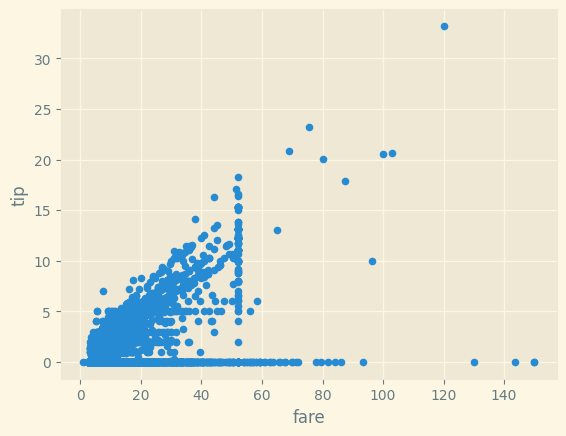

In [20]:
df.plot(kind='scatter',x='fare',y='tip')

### Observation

* **The Bottom Edge (The X-Axis): This shows the "fare"—how much the actual car ride cost. It goes from $0 all the way up to $150.**

* **The Left Edge (The Y-Axis): This shows the "tip"—how much extra money the passenger gave the driver. This goes from $0 up to over $30**.

* **The Dots: Every single blue dot on this screen is one real car ride. Its position tells us exactly what the fare was and what the tip was for that specific trip.**

1. The "Good Tipper" Cloud (The Upward Slope)
Look at the big, thick cloud of dots stretching from the bottom left and angling up toward the middle. This tells us the standard rule of tipping: As the ride gets more expensive (moving right), the tip gets bigger (moving up). Most people are calculating a percentage, like 15% or 20%, so the dots naturally climb higher as the fare increases.

2. The "Cheapskate" Line (The Heavy Bottom)
Notice that perfectly straight, dark blue line running all the way across the very bottom edge, right at the $0 mark for the tip? That is the harsh reality of driving a taxi! It means that no matter how expensive the fare was—even for rides that cost $80, $100, or $140—a huge number of passengers left absolutely zero tip.

3. The "Flat Rate" Wall (The Vertical Line)
This is my favorite part of this chart. Look right at the $50 mark on the bottom fare line. Do you see how there is a straight, vertical "wall" of dots stacked right on top of each other? In the real world, rides rarely cost exactly $50.00 by coincidence. This vertical wall usually means there is a flat-rate fee, like a standard $50 charge to go to the airport. The fare stays exactly the same ($50), but different people give totally different tips (from $0 up to $18), creating that straight line up!

In [21]:
df['payment'].value_counts()

payment
credit card    4577
cash           1812
Name: count, dtype: int64

<Axes: xlabel='distance', ylabel='fare'>

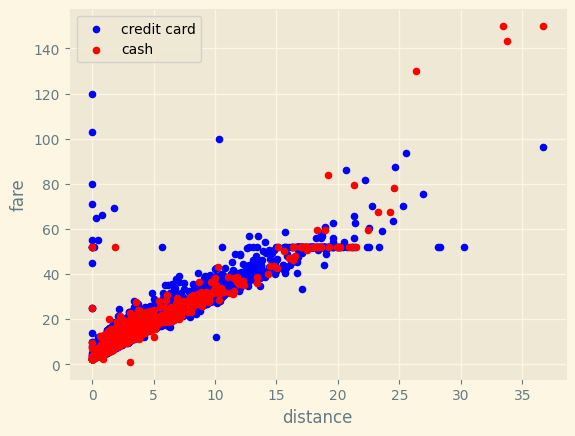

In [22]:
ax= df[df['payment']=='credit card'].plot(kind='scatter',x='distance',y='fare',color='blue',label='credit card')
df[df['payment']=='cash'].plot(kind='scatter',x='distance',y='fare',color='Red',label='cash',ax=ax)

<Axes: xlabel='distance', ylabel='tip'>

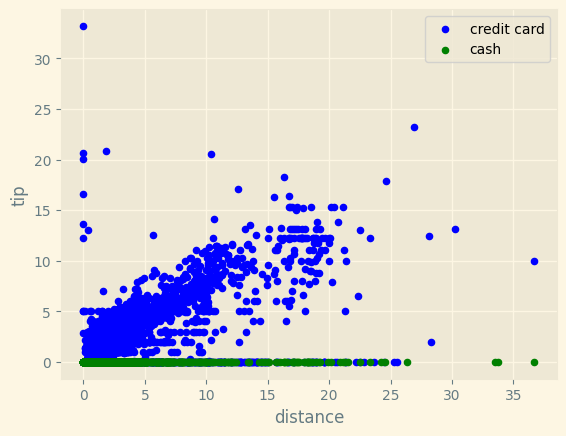

In [23]:
ax= df[df['payment']=='credit card'].plot(kind='scatter',x='distance',y='tip',color='blue',label='credit card')
df[df['payment']=='cash'].plot(kind='scatter',x='distance',y='tip',color='green',label='cash',ax=ax)

### The ax=ax command is just your way of forcing Python to overlay the cash data and the credit card data onto one single, beautiful picture so you can compare them perfectly.

In [24]:
#import seaborn as sns

# We give it the whole dataset, tell it the x and y, and use 'hue' to color by payment!
#sns.scatterplot(data=df, x='distance', y='fare', hue='payment', palette={'credit card': 'blue', 'cash': 'red'})

# Notice :- we are not using matplot or seaborn uptill now ,we are still using pandas plotting for practice

<Axes: xlabel='distance', ylabel='fare'>

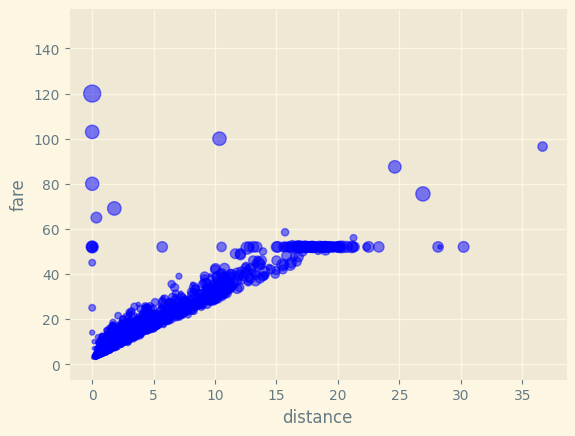

In [25]:
df.plot(kind='scatter',x='distance',y='fare',color='blue',s=df['tip']/df['tip'].max()*150,alpha=.5)

 s simply stands for "size." Instead of making every single blue dot the exact same size, you are telling Python, "Hey, make some dots giant and make some dots tiny." But Python needs to know which dots should be big and which should be small. That is exactly what the formula does. It uses the tip amount to decide the size of the dot. A bigger tip equals a bigger bubble!

The formula you used is a classic data science trick called "normalization." It might look like algebra, but it is really just figuring out a percentage. Here is how Python reads it, step-by-step:

 1. Finding the "Whale": df['tip'].max()
**First, Python looks at every single ride in your dataset to find the absolute biggest tip anyone gave all day. Let's pretend the most generous person tipped $20. That $20 is our "max."**

2. Finding the Percentage: df['tip'] / df['tip'].max()
Next, Python looks at the specific car ride it is about to draw. It takes the tip for that ride and divides it by our $20 max.

If the ride had a $10 tip, the math is 10 / 20 = 0.50 (or 50%).

If the ride had a $20 tip, the math is 20 / 20 = 1.0 (or 100%).

3. The Magnifying Glass: * 150
Here is the problem: if Python tries to draw a dot that is size "0.50" or "1.0", it will be so microscopic you won't even be able to see it on your screen.

We multiply by 150 to blow the dots up so human eyes can see them.

The absolute biggest tip (100%) gets multiplied by 150, making it a nice, big bubble of size 150.

The $10 tip (50%) gets multiplied by 150, making it a bubble of size 75.

## 🔍 Uncovering the Story in the Scatter Plot

When we visualize data, we aren't just drawing shapes; we are mapping out real-world human behavior. By examining the density and outliers in our bubble chart, we can uncover three distinct narratives hiding in plain sight:

### 1. The "Normal" Highway (The Diagonal Line)
Look at that thick, dark blue streak shooting diagonally up from the bottom left corner. This represents the standard rule of the universe for taxis: **the further you drive, the more the meter clicks up.** * It forms a beautifully straight, dense line because the taxi meter charges a predictable, set amount per mile.

---

### 2. The $50 "Shelf" (The Horizontal Line)
Notice the straight, flat line of dots floating right around the $50 mark on the Y-axis. The cars in this line drove very different distances to get to their destinations (some drove 15 miles, some drove 30 miles), but the final price stayed exactly the same. 
* **The Insight:** This is undeniable evidence of a **flat-rate fee**. In city taxi data, this almost always represents the standard, fixed charge to take a cab out to the local airport.

---

### 3. The "Parked Car" Tower (The Vertical Line at Zero)
This is where the data gets messy, and where a good analyst earns their keep. Look at the far left edge, right at the **0 distance** mark on the X-axis. There is a vertical tower of dots going straight up. Some of these rides cost over $100 and $120, and because the bubbles are giant, we know the passengers left massive tips!

> **🕵️‍♂️ The Data Detective's Conclusion:**
> How do you pay $120 and leave a huge tip when the car didn't even drive a single mile? This anomaly tells us one of three things happened in the real world:
> 1. **Hourly Waiting:** The driver was paid to sit and wait for hours (e.g., waiting outside a fancy event or running an errand).
> 2. **Courier Service:** A package was being delivered instead of a person, so the meter was run differently.
> 3. **A Data Glitch:** Human error occurred, and someone simply typed the wrong numbers into the computer system!

## Pie Chart

<Axes: ylabel='fare'>

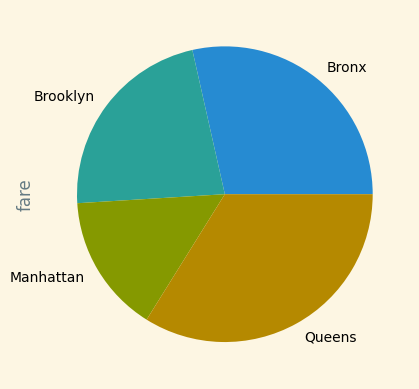

In [27]:
df.groupby('pickup_borough')['fare'].mean().plot(kind='pie')

Text(0.5, 1.0, '\n Avrage fare by pickup borough')

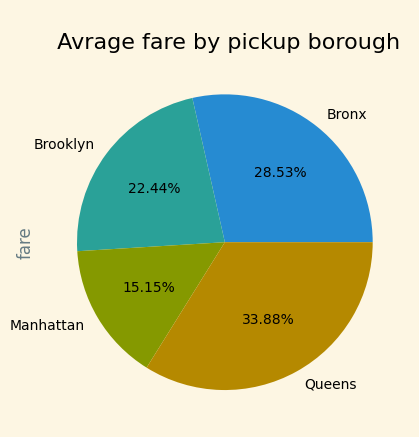

In [28]:
df.groupby('pickup_borough')['fare'].mean().plot(kind='pie',autopct='%.2f%%')
plt.title('\n Avrage fare by pickup borough')

Text(0.5, 1.0, '\n Avrage fare by pickup borough')

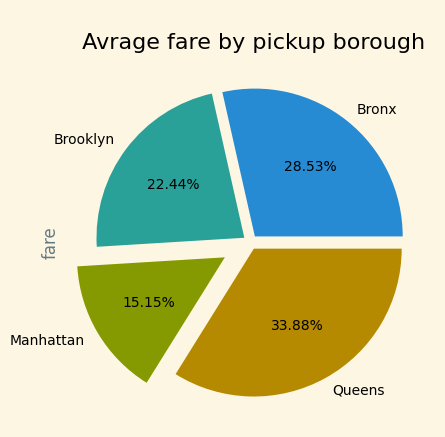

In [29]:
df.groupby('pickup_borough')['fare'].mean().plot(kind='pie',autopct='%.2f%%',explode = [.05,.05,.2,.05])
plt.title('\n Avrage fare by pickup borough')

Text(0, 0.5, '')

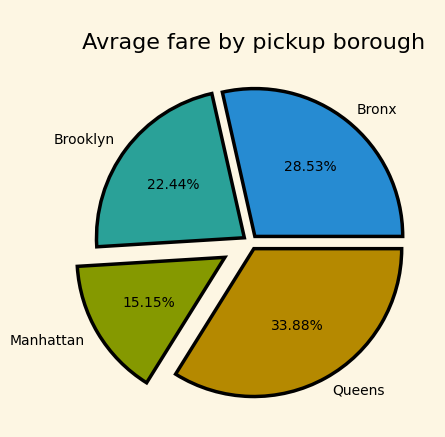

In [30]:
ax = df.groupby('pickup_borough')['fare'].mean().plot(kind='pie',autopct='%.2f%%',explode = [.05,.05,.2,.05])
plt.title('\n Avrage fare by pickup borough')

for w in ax.patches:
    w.set_linewidth(2.5)
    w.set_edgecolor('black')
ax.set_ylabel(None)

# Box Plot

In [26]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

<Axes: title={'center': 'fare'}, xlabel='dropoff_borough'>

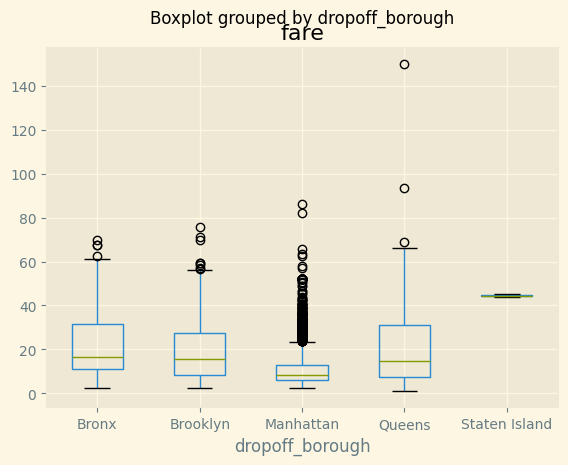

In [31]:
df.boxplot(column='fare',by='dropoff_borough')

The Box (The "Normal" Crowd): The blue rectangle represents the middle 50% of all the rides. The bottom of the box is the 25th percentile, and the top is the 75th percentile. This is where the vast majority of everyday, normal trips live.

The Green Line (The "Average Joe"): That horizontal green line slicing through the middle of the box is the median. It is the exact halfway point of all the prices.

The Whiskers (The "Fences"): The little black lines sticking out of the top and bottom are the "whiskers." They show the maximum and minimum limits of what we still consider a normal ride.

The Circles (The "Rule Breakers"): Any dots floating above the top whisker are outliers. These are the unusually expensive rides that broke the normal rules!

array([<Axes: title={'center': 'fare'}, xlabel='dropoff_borough'>,
       <Axes: title={'center': 'total'}, xlabel='dropoff_borough'>],
      dtype=object)

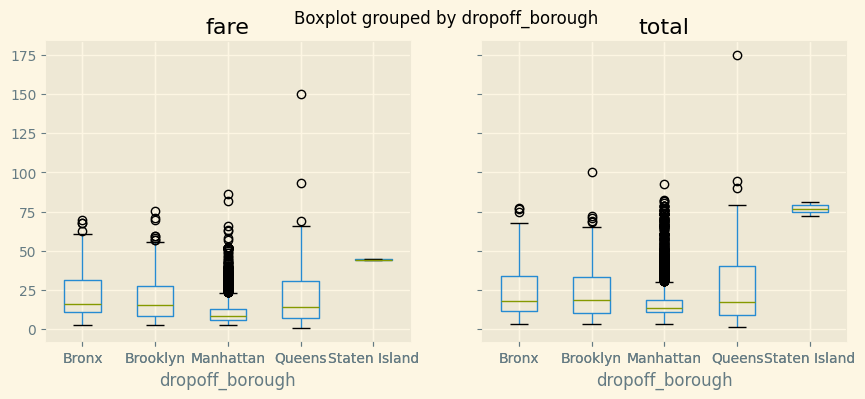

In [32]:
df.boxplot(column=['fare','total'],by='dropoff_borough',figsize=(10,4))

# 1.The Invisible Surcharges  (The Upward Shift)
## **Take a look at the blue boxes for the Bronx, Brooklyn, and Manhattan. If you look at the right chart (total), all of those boxes are floating slightly higher than they are on the left chart (fare).**

## **The Insight: That little gap between the left and the right is the real world kicking in! It perfectly maps out the extra money passengers are paying in tips and taxes. The trips didn't get longer; they just got more expensive at the checkout screen.**

# 2. The Staten Island Reveal (The Biggest Clue)
## **Look at Staten Island on the right (total). It suddenly jumped way up to almost $80, and it turned into a real, hollow box!**

## **The Insight: Why would a $45 flat-rate suddenly jump to $80? Tolls! Getting to Staten Island requires crossing expensive bridges. The base fare stays the same, but the massive toll gets added at the end. It turns into a box because passengers are giving slightly different tips on top of that expensive final bill.**

# 3. The Extremes Get More Extreme
## **Look at the crazy "rule breaker" dots floating way up at the top for Queens.**

## **On the left chart, the most expensive ride on the meter was exactly $150.**

## **On the right chart, that exact same ride jumps up to nearly $175!**

## **The Insight: Whoever took that massive trip didn't just pay a huge fare; they also left a very generous $25 tip (or hit some heavy tolls) along the way.**

In [34]:
color = dict(boxes='Blue',whiskers='Purple',medians='Green',caps='Gray')
color

{'boxes': 'Blue', 'whiskers': 'Purple', 'medians': 'Green', 'caps': 'Gray'}

<Axes: title={'center': 'fare'}, xlabel='dropoff_borough'>

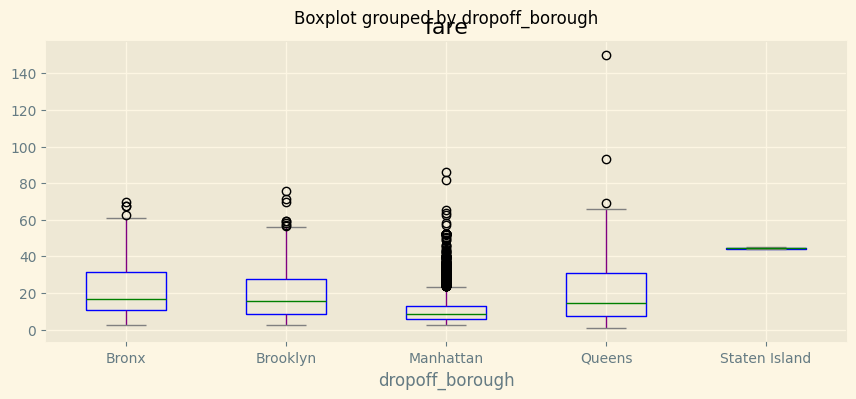

In [35]:
df.boxplot(column='fare',by='dropoff_borough',figsize=(10,4),color=color,)

/tmp/ipykernel_55/1774577749.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


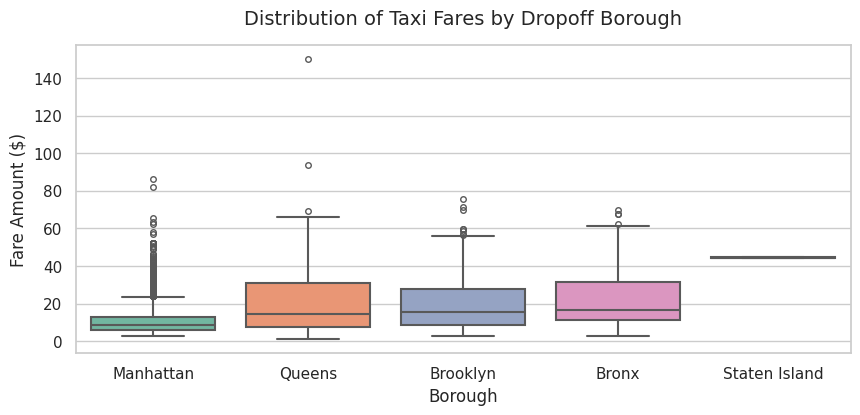

In [37]:
#import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a beautiful, clean background theme
sns.set_theme(style="whitegrid")

# 2. Set the size of your canvas
plt.figure(figsize=(10, 4))

# 3. Draw the modern boxplot
# We use 'palette' to give each borough a distinct, pleasing color
sns.boxplot(data=df, 
            x='dropoff_borough', 
            y='fare', 
            palette='Set2',  
            linewidth=1.5,      # Makes the lines a bit thicker and crisper
            fliersize=4)        # Makes those outlier "rule breaker" dots a bit smaller and neater

# 4. Clean up the labels so they look professional
plt.title('Distribution of Taxi Fares by Dropoff Borough', fontsize=14, pad=15)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)

# 5. Show the masterpiece!
plt.show()

# Scatter Matrix

## **Multivariate Data Vizualisation**
## **Qick Insights**
##  **Parwise Comparison**

In [38]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

array([[<Axes: xlabel='fare', ylabel='fare'>,
        <Axes: xlabel='tip', ylabel='fare'>,
        <Axes: xlabel='total', ylabel='fare'>],
       [<Axes: xlabel='fare', ylabel='tip'>,
        <Axes: xlabel='tip', ylabel='tip'>,
        <Axes: xlabel='total', ylabel='tip'>],
       [<Axes: xlabel='fare', ylabel='total'>,
        <Axes: xlabel='tip', ylabel='total'>,
        <Axes: xlabel='total', ylabel='total'>]], dtype=object)

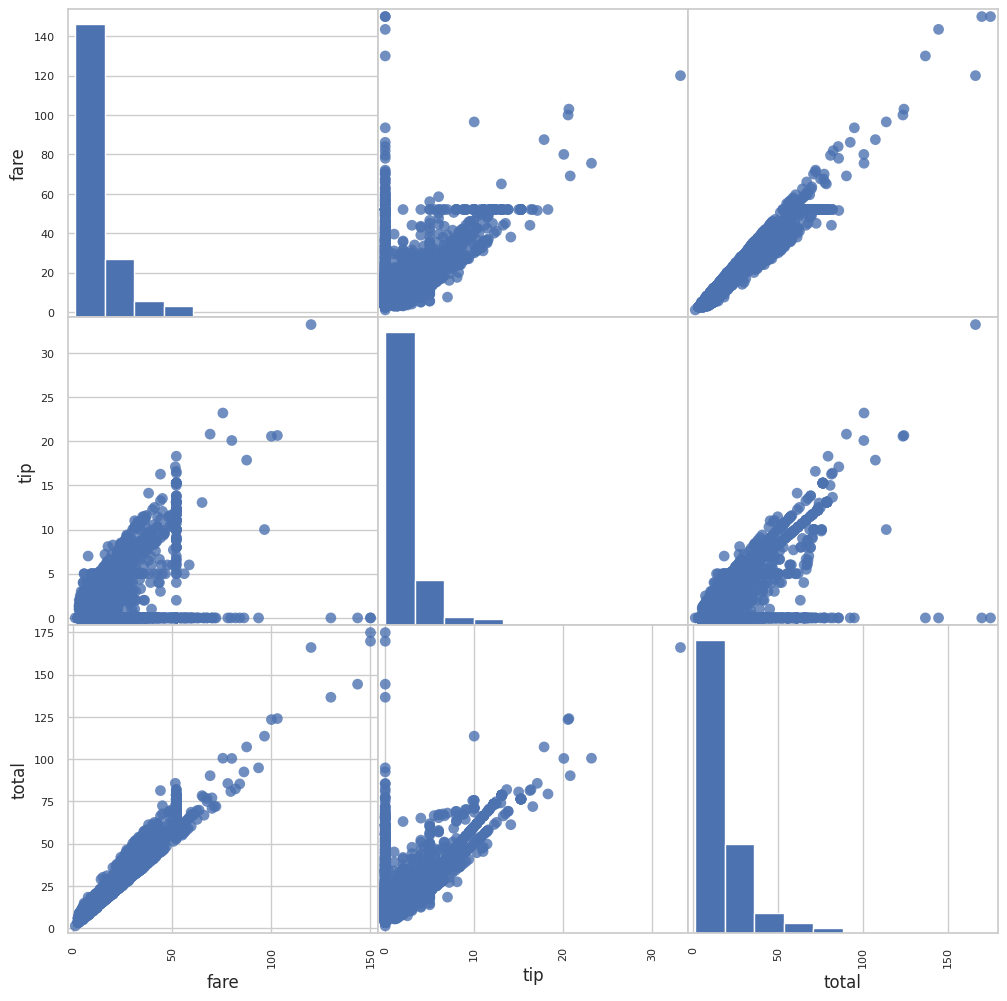

In [40]:
pd.plotting.scatter_matrix(df[['fare', 'tip','total',]],figsize=(12,12),marker='o',hist_kwds={'bins':10},s=60,alpha=.8)